In [1]:
# import libraries
import os
import sys
sys.path.insert(0, '..')

import mlflow
import pandas as pd
from sklearn.model_selection import train_test_split
from pathlib import Path

from src.data.load_data import load_raw_data, encode_target
from src.data.clean_data import clean_pipeline
from src.features.build_features import build_features_pipeline
from src.models.train import run_all_models
from src.models.stacking import train_and_evaluate_stacking
from src.models.preprocessing import fit_frequency_encoders, apply_frequency_encoders, high_cardinality_cols
from src.models.evaluate import final_optimal_threshold, get_confusion_matrix
from src.business.roi_simulation import compare_f1_vs_roi_thresholds

from src.models.preprocessing import all_model_features
from src.explainability.fairness_audit import subgroup_performance, flag_disparate_subgroups

In [2]:
# load raw data
data = encode_target(load_raw_data('../data/raw/bank-full.csv'))
cleaned = clean_pipeline(data)
print("Data loaded and cleaned successfully.")

Data loaded and cleaned successfully.


In [3]:
train_data, temp_data = train_test_split(cleaned, test_size=0.2, random_state=42, stratify=cleaned['y'])  # train-test split
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42, stratify=temp_data['y'])  # validation-test split
train_features, train_target = build_features_pipeline(train_data, {'val' : val_data, 'test' : test_data})

In [4]:
# train and compare five models: Logistic Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Bank Marketing Classification")
comparison_df = run_all_models(train_features, train_target['test'])
comparison_df.sort_values('average_precision', ascending=False)

Training and evaluating Logistic Regression...
{'model_name': 'stacked_ensemble', 'accuracy': 0.8920115069705687, 'precision': 0.5850622406639004, 'recall': 0.2665406427221172, 'f1_score': 0.36623376623376624, 'roc_auc': 0.7938091921675645, 'average_precision': 0.4422651625594388}


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[done] Logistic Regression : ROC AUC = 0.7679, F1 Score = 0.3776 PR-AUC = 0.3982
Training and evaluating K-Nearest Neighbors...
{'model_name': 'stacked_ensemble', 'accuracy': 0.8920115069705687, 'precision': 0.5850622406639004, 'recall': 0.2665406427221172, 'f1_score': 0.36623376623376624, 'roc_auc': 0.7938091921675645, 'average_precision': 0.4422651625594388}
[done] K-Nearest Neighbors : ROC AUC = 0.7455, F1 Score = 0.3306 PR-AUC = 0.3830
Training and evaluating Random Forest...
{'model_name': 'stacked_ensemble', 'accuracy': 0.8920115069705687, 'precision': 0.5850622406639004, 'recall': 0.2665406427221172, 'f1_score': 0.36623376623376624, 'roc_auc': 0.7938091921675645, 'average_precision': 0.4422651625594388}
[done] Random Forest : ROC AUC = 0.7859, F1 Score = 0.4464 PR-AUC = 0.4250
Training and evaluating XGBoost...
{'model_name': 'stacked_ensemble', 'accuracy': 0.8920115069705687, 'precision': 0.5850622406639004, 'recall': 0.2665406427221172, 'f1_score': 0.36623376623376624, 'roc_au

,model_name,accuracy,precision,recall,f1_score,roc_auc,average_precision
3,XGBoost,0.832485,0.372768,0.631380,0.468772,0.797925,0.450340
4,Neural Network,0.893339,0.645963,0.196597,0.301449,0.774359,0.427039
2,Random Forest,0.844656,0.382950,0.534972,0.446372,0.785856,0.424968
0,Logistic Regression,0.751936,0.267296,0.642722,0.377568,0.767866,0.398224
1,K-Nearest Neighbors,0.890684,0.583732,0.230624,0.330623,0.745475,0.382973


In [5]:
# stacked model
freq_encoders = fit_frequency_encoders(train_features, high_cardinality_cols)
train_encoders = apply_frequency_encoders(train_features, freq_encoders)
test_encoders = apply_frequency_encoders(train_target['test'], freq_encoders)
stack_result = train_and_evaluate_stacking(train_features, train_target['test'], train_encoders, test_encoders)
print({k: v for k, v in stack_result.items() if k != 'pipeline'})

{'model_name': 'stacked_ensemble', 'accuracy': 0.8920115069705687, 'precision': 0.5850622406639004, 'recall': 0.2665406427221172, 'f1_score': 0.36623376623376624, 'roc_auc': 0.7938091921675645, 'average_precision': 0.4422651625594388}


In [6]:
# Threshold tuning + confusion-matrix breakdown for the best model
from src.models.train import get_base_model, train_and_evaluate_model

n_pos = (train_features['y'] == 1).sum()
n_neg = (train_features['y'] == 0).sum()
best_model_name = comparison_df.sort_values('average_precision', ascending=False).iloc[0]['model_name']
estimator, need_scaler = get_base_model(n_neg/n_pos)[best_model_name]

# Re-fit the winner once more so we have a fitted pipeline object to reuse
best_result = train_and_evaluate_model(best_model_name, estimator, need_scaler, train_features, train_target['test'])
y_test = test_encoders['y']
print(f"Best model: {best_model_name}, test precision: {best_result['precision']:.4f}, test recall: {best_result['recall']:.4f}")


{'model_name': 'stacked_ensemble', 'accuracy': 0.8920115069705687, 'precision': 0.5850622406639004, 'recall': 0.2665406427221172, 'f1_score': 0.36623376623376624, 'roc_auc': 0.7938091921675645, 'average_precision': 0.4422651625594388}
Best model: XGBoost, test precision: 0.3728, test recall: 0.6314


In [7]:
# ROI analysis - F1 optimal vs ROI optimal threshold
y_proba = best_result['pipeline'].predict_proba(test_encoders[all_model_features])[:, 1]
thresholds_df = final_optimal_threshold(y_test, y_proba)
print("Thresholds for F1 and ROI optimization:")
print(thresholds_df)

roi_comparison_df = compare_f1_vs_roi_thresholds(y_test.values, y_proba, thresholds_df['threshold'])
roi_comparison_df

Thresholds for F1 and ROI optimization:
{'threshold': 0.5800000000000001, 'f1_score': 0.49370277078085645, 'recall': 0.555765595463138, 'precision': 0.44410876132930516}


,strategy,threshold,calls_made,conversions,revenue,cost,net_value
0,F1-optimal,0.58,662.0,294.0,35280.0,5296.0,29984.0
1,ROI-optimal,0.36,1655.0,403.0,48360.0,13240.0,35120.0


In [8]:
# Fairness audit across client subgroups
audit_df = test_encoders.copy()
audit_df['y_pred'] = (y_proba >= thresholds_df['threshold']).astype(int)
audit_df['y_proba'] = y_proba

subgroup_performance_df = subgroup_performance(audit_df, 'y', 'y_pred', 'y_proba', 'age_life_stage')
subgroup_performance_df

,age_life_stage,n_clients,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,Young Adult,519,0.776493,0.401408,0.647727,0.495652,0.785646,0.442396
1,family_formation,2391,0.884985,0.451493,0.485944,0.468085,0.796392,0.437997
2,pre_retirement,1436,0.896240,0.448980,0.492537,0.469751,0.752797,0.414982
3,retired,173,0.635838,0.476190,0.862069,0.613497,0.752774,0.578678
4,OVERALL,4519,0.866563,0.444109,0.555766,0.493703,0.797925,0.450340


In [9]:
flag_disparate_subgroups(subgroup_performance_df, metric='recall', tolerance=0.1)

,age_life_stage,n_clients,accuracy,precision,recall,f1_score,roc_auc,average_precision,gap_vs_overall


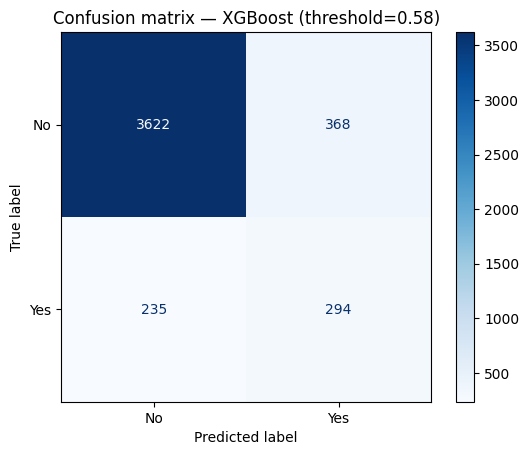

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = (y_proba >= thresholds_df['threshold']).astype(int)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(cmap='Blues', values_format='d')
plt.title(f"Confusion matrix — XGBoost (threshold={thresholds_df['threshold']:.2f})")
plt.show()

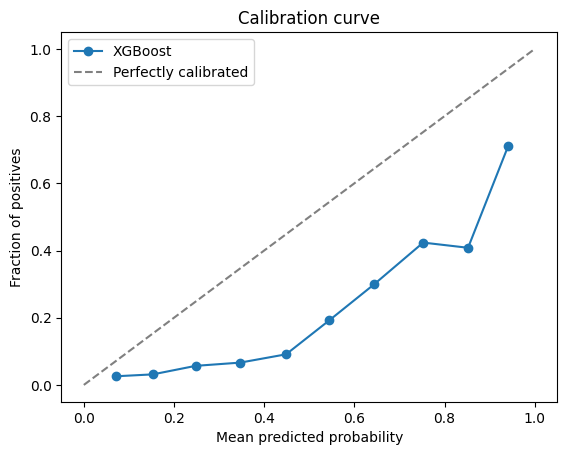

In [11]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction of positives')
plt.legend(); plt.title('Calibration curve'); plt.show()

In [12]:
from src.explainability.fairness_audit import subgroup_performance

job_performance_df = subgroup_performance(audit_df, 'y', 'y_pred', 'y_proba', 'job')
month_performance_df = subgroup_performance(audit_df, 'y', 'y_pred', 'y_proba', 'month')
job_performance_df

,job,n_clients,accuracy,precision,recall,f1_score,roc_auc,average_precision
0,admin.,527,0.861480,0.439024,0.571429,0.496552,0.794677,0.370570
1,blue-collar,947,0.929250,0.437500,0.344262,0.385321,0.709396,0.333925
2,entrepreneur,143,0.895105,0.400000,0.307692,0.347826,0.739053,0.303809
3,housemaid,133,0.894737,0.562500,0.562500,0.562500,0.834936,0.506846
4,management,1002,0.843313,0.456647,0.556338,0.501587,0.807026,0.491309
5,retired,222,0.720721,0.372093,0.800000,0.507937,0.813462,0.527659
6,self-employed,147,0.850340,0.476190,0.476190,0.476190,0.708617,0.377813
7,services,387,0.904393,0.515152,0.447368,0.478873,0.736465,0.387387
8,student,106,0.679245,0.458333,0.733333,0.564103,0.761842,0.556359
9,technician,751,0.874834,0.446429,0.609756,0.515464,0.831547,0.541084


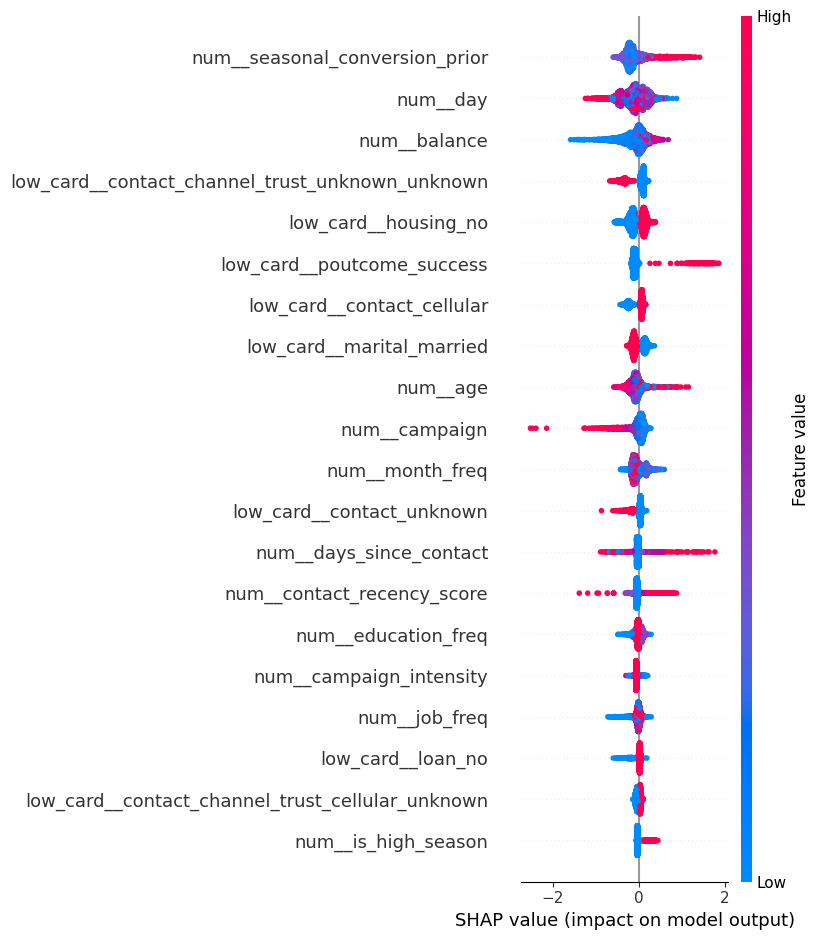

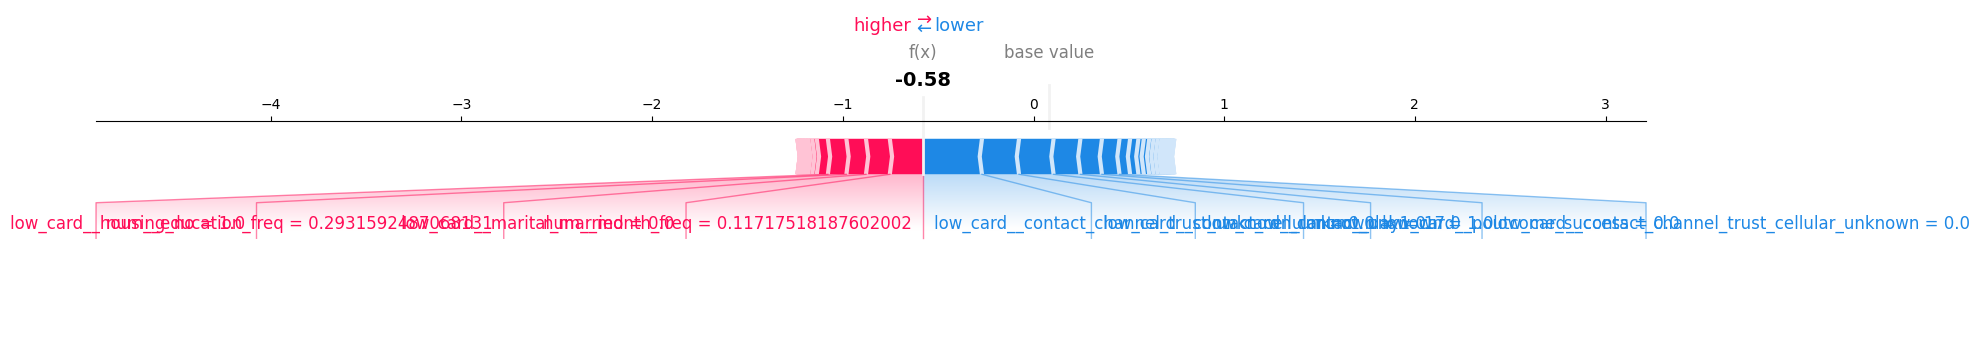

NameError: name 'idx_of_a_borderline_client' is not defined

In [14]:

import shap, pandas as pd, numpy as np

preprocessor = best_result['pipeline'].named_steps['preprocessor']
classifier = best_result['pipeline'].named_steps['classifier']
feature_names = list(preprocessor.get_feature_names_out())

X_test_transformed = pd.DataFrame(
    preprocessor.transform(test_encoders[all_model_features]), columns=feature_names
)

# Summary plot
shap_values = shap.TreeExplainer(classifier)(X_test_transformed)
shap.summary_plot(shap_values, X_test_transformed)

# Force plot for two individual clients
shap.plots.force(shap_values[0], matplotlib=True)
shap.plots.force(shap_values[idx_of_a_borderline_client], matplotlib=True)  # reuse the idx from your threshold-tuning cell

# Interaction heatmap (sample for speed — this is O(features²))
import seaborn as sns
sample = X_test_transformed.sample(200, random_state=42)
interactions = shap.TreeExplainer(classifier).shap_interaction_values(sample)
mean_abs = np.abs(shap_values.values).mean(axis=0)
top10_idx = np.argsort(-mean_abs)[:10]
top10_names = [feature_names[i] for i in top10_idx]
heat = np.abs(interactions).mean(axis=0)[np.ix_(top10_idx, top10_idx)]
sns.heatmap(heat, xticklabels=top10_names, yticklabels=top10_names, cmap='Reds')
plt.title('SHAP interaction strength (top 10 features)'); plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd, numpy as np
from lime.lime_tabular import LimeTabularExplainer
from src.models.preprocessing import LOW_CARDINALITY_CATEGORICAL, all_model_features

X_train_lime = train_encoders[all_model_features].reset_index(drop=True)
X_test_lime = test_encoders[all_model_features].reset_index(drop=True)

category_maps, X_train_enc, X_test_enc = {}, X_train_lime.copy(), X_test_lime.copy()
for col in LOW_CARDINALITY_CATEGORICAL:
    cats = sorted(X_train_lime[col].unique())
    category_maps[col] = cats
    code_map = {c: i for i, c in enumerate(cats)}
    X_train_enc[col] = X_train_lime[col].map(code_map)
    X_test_enc[col] = X_test_lime[col].map(code_map).fillna(-1)

cat_idx = [X_train_enc.columns.get_loc(c) for c in LOW_CARDINALITY_CATEGORICAL]
cat_names = {X_train_enc.columns.get_loc(c): category_maps[c] for c in LOW_CARDINALITY_CATEGORICAL}

explainer = LimeTabularExplainer(
    X_train_enc.values.astype(float), feature_names=list(X_train_enc.columns),
    categorical_features=cat_idx, categorical_names=cat_names,
    class_names=["no", "yes"], mode="classification",
)

def predict_fn(data_array):
    df = pd.DataFrame(data_array, columns=all_model_features)
    for col in LOW_CARDINALITY_CATEGORICAL:
        df[col] = df[col].round().astype(int).map(lambda i: category_maps[col][i])
    return best_result['pipeline'].predict_proba(df)

borderline_idx = np.argsort(np.abs(y_proba - thresholds_df['threshold']))[:5]
for i in borderline_idx:
    exp = explainer.explain_instance(X_test_enc.iloc[i].values.astype(float), predict_fn, num_features=8)
    print(f"Client {i}, predicted probability {y_proba[i]:.3f}")
    for feat, weight in exp.as_list():
        print(f"  {feat}: {weight:.4f}")
    print()

In [ ]:
mean_abs = np.abs(shap_values.values).mean(axis=0)
for i in np.argsort(-mean_abs)[:5]:
    print(feature_names[i], mean_abs[i])